In [ ]:
#Testing the git push from VScode local

In [2]:
import sklearn
import pandas as pd
import numpy as np
from numpy import errstate,isneginf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from tqdm import tqdm
from tqdm import trange
from collections import Counter

from sklearn.decomposition import PCA

#import umap

import zipfile
import os
import json
import requests
import io
import copy
#import biomart
#import umap


~30 seconds to read TCGA data, ~7 seconds to read STMFR data

In [3]:
tcga_file_path = '/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Data/tcga_final_data.csv'

# tcga_file_path = '/home/swapnanil_mukherjee/cancer_data/tcga_final_data.csv'

tcga = pd.read_csv(tcga_file_path)

In [4]:
# stmfr_file_path = '/home/bhavesh/Documents/PhD/model_agreement_expr/stmfr_4_classes.csv'

stmfr_file_path = '/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Data/stmfr_4_classes.csv'
df= pd.read_csv(stmfr_file_path)

# print(df.shape)


df.set_index(df.loc[:, '0'], inplace=True)
df.drop('0', axis=1, inplace=True)

In [5]:
tcga.set_index(tcga.loc[:, "Unnamed: 0"], inplace=True)
tcga.drop("Unnamed: 0", axis=1, inplace=True)
cols = df.columns.tolist()
cols_ = cols[:-1]

tcga = tcga[cols_]

In [ ]:
# print(df['label'].value_counts())

hMSC    997
iPSC    896
hUSC    816
hESC    585
Name: label, dtype: int64


In [6]:
label_encoder = LabelEncoder()
df['numeric_label'] = label_encoder.fit_transform(df.label)
df.drop('label', axis=1, inplace=True)

In [ ]:
# print(df['numeric_label'].value_counts())
# print(label_encoder.classes_)

1    997
3    896
2    816
0    585
Name: numeric_label, dtype: int64
['hESC' 'hMSC' 'hUSC' 'iPSC']


In [7]:
global box_plot_num 
box_plot_num = 0
global model_prediction_agreement 
model_prediction_agreement = 0

In [8]:
# Creating plot
# plt.boxplot(model_acc_list, patch_artist = True,
#                 notch ='True', vert = 0)
def box_plot_models_accuracy(model_acc_list):

    plt.rcParams.update({'font.size': 8})


    global box_plot_num
    # fig = plt.figure(figsize =(6, 4))    
    plt.boxplot(model_acc_list, vert = 0, )

    plt.xlabel("accuracy")
    # plt.title('PCA with 500 components\n 90-10 data split')   # Change the font setting for the title 
    fname = 'boxplot_'+str(box_plot_num)+'.png'
    box_plot_num = box_plot_num + 1
    plt.savefig(fname)
    plt.close()


In [9]:
def get_agreement_rate(model_pred, n_models, len_tcga):

    model_pred_results = pd.DataFrame(model_pred)
    # model_pred_results.to_csv("model_agreements.csv", index=False)
    model_pred_results_len = len(model_pred_results.columns)
    min_agree_list = []

    count_models = n_models # For prototyping use 5, and change it back to 100
    samples_index = []

    low = np.int16(np.ceil(0.4*count_models))
    high = count_models + 1

    

    # for min in range(40,101):
    for min in range(low,high):     
        c = 0
        for i in range(model_pred_results_len):
            counter_values = list(Counter(model_pred_results[i]).values())
            if any(j >= min for j in counter_values):
                c+=1
                if(min == count_models):
                    samples_index.append([i, model_pred_results[i][0]])
                    # print (i, model_pred_results[i])
        agree_score = c/len_tcga
        min_agree_list.append([min, agree_score])

    min_agree_df = pd.DataFrame(min_agree_list)

    return samples_index, min_agree_df

In [10]:
def plot_model_accuracy(min_agree_df, len_train, len_test, len_ood):

    global model_prediction_agreement
    x = min_agree_df[0]
    y = min_agree_df[1]

    # make data
    # x = np.linspace(0, 10, 100)
    # y = 4 + 2 * np.sin(2 * x)

    # plot
    fig, ax = plt.subplots()

    ax.plot(x, y, linewidth=2.0)

    # ax.set(xlim=(0, 100),
    #        ylim=(0, 1.1),)

    for i,j in zip(x,y):
        if(i in (40, 60, 70, 80, 90, 100)):
            ax.annotate(f"{j:.1%}",xy=(i,j))


    ax.set(ylim=(0, 1.1))
    plt.xlabel('Number of models')
    plt.ylabel('% agreement')
    plt.title('Train: '+str(len_train)+' Test: '+str(len_test)+' OOD: '+str(len_ood))
    fname = 'model_agreement_percent_'+str(model_prediction_agreement)+'.png'
    model_prediction_agreement = model_prediction_agreement + 1
    plt.savefig(fname)
    plt.close()

In [11]:
def merge_samples_tcga_stmfr(samples_index, stmfr_df, tcga_df):
    
    samples_index_df = pd.DataFrame(samples_index)
    # samples_index_df
    selected_tcga_samples = tcga_df.iloc[samples_index_df[0]]
    
    ood_index = list(set(range(len(tcga_df))) - set(samples_index_df[0]))
    
    ood_tcga_samples = tcga_df.iloc[ood_index]

    selected_tcga_samples.loc[:,"numeric_label"] = list(samples_index_df[1])

    if len(selected_tcga_samples) == 1:
        combined_train_stmfr_tcga = pd.concat([stmfr_df, selected_tcga_samples])
        return combined_train_stmfr_tcga, "", ood_tcga_samples
    else:
        selected_tcga_samples_train, selected_tcga_samples_test = train_test_split(selected_tcga_samples, test_size=0.2, random_state=42, shuffle=True) 
        combined_train_stmfr_tcga = pd.concat([stmfr_df, selected_tcga_samples_train])
        return combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples

In [23]:
import xgboost as xgb
from xgboost import XGBClassifier

# train, test = train_test_split(df, test_size=0.3, random_state=42, shuffle=True)

# train, test = train_test_split(stmfr_data_train, test_size=0.1, random_state=i, shuffle=True)

# X_train, y_train = train.iloc[:, :-1], train['numeric_label']
# X_test, y_test = test.iloc[:, :-1], test['numeric_label']

x = df.iloc[:, :-1]
y = df['numeric_label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in skf.split(x, y):
    
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    bst = XGBClassifier(n_estimators=2, max_depth=20, learning_rate=1, num_class=4, objective='multi:softmax')
    # fit model
    bst.fit(X_train, y_train)
    # make predictions
    predictions = bst.predict(X_test)

    # pca = PCA(n_components=100)
    # X_train_pca = pca.fit_transform(X_train)
    # X_test_pca = pca.transform(X_test)

    # dtrain = xgb.DMatrix(X_train_pca, label=y_train)
    # dtrain.save_binary('train.buffer')

    # param = {'max_depth': 20, 'eta': 1, 'objective': 'multi:softmax'}
    # param['nthread'] = 4
    # param['eval_metric'] = 'auc'
    # param['num_class'] = 4

    # num_round = 10
    # bst = xgb.train(param, dtrain, num_round)

    # dtest = xgb.DMatrix(X_test_pca)
    # predictions = bst.predict(dtest)

    target_names = ['hESC', 'hMSC', 'hUSC', 'iPSC']
    # print(classification_report(y_test, predictions, target_names=target_names))

    # model_acc = accuracy_score(y_test, predictions, normalize=True)
    # model_acc

    accuracy = accuracy_score(y_test, predictions)
    b_accuracy = balanced_accuracy_score(y_test, predictions)
    f1score = f1_score(y_test, predictions, average='weighted')
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')

    print(accuracy, end='\t')
    # m.append(accuracy)

    print(b_accuracy, end='\t')
    print(f1score, end='\t')
    print(precision, end='\t')
    print(recall)


    # xgb.plot_importance(bst)

    # xgb.plot_tree(bst, num_trees=2)
    # xgb.to_graphviz(bst, num_trees=2)

0.9332321699544764	0.9292133973633957	0.9331661308263884	0.9332591886761575	0.9332321699544764
0.9347496206373292	0.9234736393025884	0.9337529634413765	0.9356336371451833	0.9347496206373292
0.928679817905918	0.9233439539992574	0.9284540559866622	0.9286628884989018	0.928679817905918
0.928679817905918	0.9226575466868189	0.9284389035067347	0.9287580748864046	0.928679817905918
0.925531914893617	0.9238353809661611	0.9256649416276207	0.9266505335116684	0.925531914893617


Max depth = 20, 90/10
with all features Xgboost acc = 94.55
with 100 PCA , 0.9363636363636364 , 0.9545454545454546 , 0.9575757575757575, 0.9515151515151515
with 55 PCA, 0.9424242424242424


70/30

100 PCA , 0.9332659251769464 , 0.9362992922143579 

Max depth = 20, 70/30, w/o PCA,0.9433771486349848, 2m 34.2s
Max depth = 20, 70/30, 100 PCA,0.9332659251769464, 58.2s, 0.9322548028311426(45.0s)

In [46]:
model_acc

0.9433771486349848

In [42]:
def prediction_agreement_models(stmfr_df, tcga_df, held_out_data="", n_models= 100, pca=True, pca_n_components=100):

    n = n_models
    model_acc_list = []
    val_acc_list = []
    model_pred = []
    df = stmfr_df
    tcga = tcga_df

    val_data = False

    # pca_n_comps = [1, 5, 10, 50, 100, 500, 1000, 2000]
    # pca_n_comps = [200, 300, 400, 600, 700, 800, 900]

    for i in tqdm(range(n)):
    # for i in pca_n_comps:
        train, test = train_test_split(df, test_size=0.1, random_state=i, shuffle=True)

        # train, test = train_test_split(stmfr_data_train, test_size=0.1, random_state=i, shuffle=True)

        X_train, y_train = train.iloc[:, :-1], train['numeric_label']
        X_test, y_test = test.iloc[:, :-1], test['numeric_label']

        # scaler = preprocessing.StandardScaler().fit(X_train)
        # pipe = make_pipeline(StandardScaler(), LinearSVC(dual = True, max_iter=10000))
        # pipe.fit(X_train, y_train)
        # pipe.score(X_test, y_test)

        # print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
        if pca:
                
            pca = PCA(n_components=pca_n_components)
            X_train_pca = pca.fit_transform(X_train)
            X_test_pca = pca.transform(X_test)
            tcga_pca = pca.transform(tcga)
            
            # model = LinearSVC(dual = False, max_iter=10000)
        else:
            X_train_pca = X_train
            X_test_pca = X_test
            tcga_pca = tcga

            # model = LinearSVC(dual = True, max_iter=10000)

        
        # model_coeffs = model.coef_
        # mlp_model = MLPClassifier(hidden_layer_sizes=[10, 10], solver='sgd', batch_size=256, max_iter=100)

        dtrain = xgb.DMatrix(X_train_pca, label=y_train)
        # dtrain.save_binary('train.buffer')

        param = {'max_depth': 20, 'eta': 1, 'objective': 'multi:softmax'}
        param['nthread'] = 4
        param['eval_metric'] = 'auc'
        param['num_class'] = 4

        num_round = 10
        model = xgb.train(param, dtrain, num_round)

        dtest = xgb.DMatrix(X_test_pca)
        predictions = model.predict(dtest)

        # model.fit(X_train_pca, y_train)
        # predictions = model.predict(X_test_pca)

        try:   
            if not held_out_data.empty:
                val_data = True
                X_validation, y_validation = held_out_data.iloc[:, :-1], held_out_data['numeric_label']
                if pca:
                    X_validation_pca = pca.transform(X_validation)
                else:
                    X_validation_pca = X_validation

                dvalid = xgb.DMatrix(X_validation_pca)
                validation_prediction = model.predict(dvalid)
                validation_prediction_acc = accuracy_score(y_validation, validation_prediction, normalize=True)
                val_acc_list.append(validation_prediction_acc)
                print("For", i, "model's accuracy on heldout tcga data: ", validation_prediction_acc)
        except AttributeError:
            pass

        # report = classification_report(y_test, predictions, output_dict=True)
        model_acc = accuracy_score(y_test, predictions, normalize=True)
        model_acc_list.append(model_acc)
        # print("For", i, "LinearSVC accuracy: ", model_acc)

        dvalid = xgb.DMatrix(tcga_pca)
        model_pred.append(model.predict(dvalid))
        # model_pred.append(model.predict(stmfr_data_predict))

        # results = pd.DataFrame(report).transpose()
        # results = results.round({'precision': 2, 'recall': 2, 'f1-score': 2, 'support':1})
        # model.predict(tcga)
        

    print("For", n, "models, test accuracy avg and stddev: ", np.mean(model_acc_list), np.std(model_acc_list))
    if(val_data):
        print("For", n, "models, validation accuracy (on held out OOD:tcga) avg and stddev: ", np.mean(val_acc_list), np.std(val_acc_list))

    box_plot_models_accuracy(model_acc_list)
    samples_index, min_agree_df = get_agreement_rate(model_pred,n ,len(tcga))
    plot_model_accuracy(min_agree_df, len(X_train), len(X_test), len(tcga))
    combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples = merge_samples_tcga_stmfr(samples_index, stmfr_df, tcga_df)
    
    
    return combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples

In [ ]:

combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples = prediction_agreement_models(df, tcga, "", n_models=100, pca=True, pca_n_components=100)

print("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: ",

                len(combined_train_stmfr_tcga), len(selected_tcga_samples_test), len(ood_tcga_samples))

2m 57.8s, 3 models, 100 PCA
For 3 models, test accuracy avg and stddev:  0.9555555555555556 0.01737843488291437
Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga:  7009 929 6426

w/o PCA, 3 models 

In [45]:
while True:
    try:
        if len(ood_tcga_samples) > 0.005*len(tcga):
            combined_train_stmfr_tcga, selected_tcga_samples_test, ood_tcga_samples = prediction_agreement_models(
                combined_train_stmfr_tcga, ood_tcga_samples, selected_tcga_samples_test, n_models=3, pca_n_components=2)
            print("Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga: ",
                len(combined_train_stmfr_tcga), len(selected_tcga_samples_test), len(ood_tcga_samples))
        else:
            print("No of samples in OOD is less than 5% of the original")
            break
    except TypeError:
        break

100%|██████████| 3/3 [00:28<00:00,  9.41s/it]
/var/folders/rf/3w2r5qss4cg6yvzsxmr48cl00000gn/T/ipykernel_24219/4058457949.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_tcga_samples.loc[:,"numeric_label"] = list(samples_index_df[1])


For 3 models, test accuracy avg and stddev:  0.7510620220900593 0.008692160437962546
For 3 models, validation accuracy (on held out OOD:tcga) avg and stddev:  0.9176896443185395 0.00022257059527432558
Length of combined_train_stmfr_tcga, selected_tcga_test, ood_tcga:  12141 95 10
No of samples in OOD is less than 5% of the original


In [ ]:
len(combined_train_stmfr_tcga), len(selected_tcga_samples_test), len(ood_tcga_samples)

(12107, 200, 53)

In [ ]:
combined_train_stmfr_tcga

Reading combined file takes around 28 secs

In [40]:
combined_stmfr_tcga_labeled = pd.read_csv('/Users/bhavesh/Library/CloudStorage/GoogleDrive-bhavesh.neekhra_phd18@ashoka.edu.in/My Drive/CR_Data/Results/MLCB/combined_stmfr_tcga_labelled.csv')

In [41]:
combined_stmfr_tcga_labeled_df = combined_stmfr_tcga_labeled

In [42]:
# tcga_labeled_df = combined_stmfr_tcga_labeled.loc[combined_stmfr_tcga_labeled['Unnamed: 0'].str.contains('TCGA')==True]
# tcga_labeled_df.set_index(tcga_labeled_df['Unnamed: 0'], inplace=True)
# tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)


combined_stmfr_tcga_labeled_df.set_index(combined_stmfr_tcga_labeled_df['Unnamed: 0'], inplace=True)
combined_stmfr_tcga_labeled_df.drop('Unnamed: 0', axis=1, inplace=True)

In [11]:
combined_stmfr_tcga_labeled_df

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,numeric_label
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
7350_GSM2871131,-0.662465,-0.452173,-1.366386,-0.957116,-0.582066,-1.206935,-1.446136,-0.281347,-0.963616,-1.147786,...,-0.691654,-0.740644,-0.543299,-0.861714,-0.663446,-0.226101,-0.660147,-1.659454,-1.229186,0
7350_GSM2871132,-0.487142,-1.025886,-1.330880,-1.142515,-0.686235,-1.185022,-1.446136,-0.157531,-1.039952,-1.426006,...,-0.990348,-0.514260,-0.634073,-0.863995,-0.772662,-0.063450,-0.661335,-1.632080,-1.072617,0
7350_GSM2871133,-0.481782,-0.416273,-1.253671,-0.808227,-0.543173,-1.277043,-1.446136,-0.171315,-0.944330,-0.594480,...,-1.574552,-0.447816,-0.490658,-0.803086,-0.846506,-0.305177,-0.570313,-1.517048,-1.193821,0
7350_GSM2871134,-0.610746,-0.161556,-1.131855,-0.942407,-0.740700,-1.216042,-1.446136,-0.112961,-0.969344,-0.736165,...,-1.586824,-0.447225,-0.596967,-0.795399,-0.871276,-0.684173,-0.538042,-1.594537,-1.339423,0
7350_GSM2871135,-0.483981,-0.420357,-1.224028,-0.975168,-0.732516,-1.375678,-1.446136,-0.268023,-0.926742,-1.068048,...,-1.501507,-0.250528,-0.416236,-0.800702,-0.845996,-0.311442,-0.559322,-1.484994,-1.054173,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-SW-A7EA-01,-1.097913,-0.051600,0.887645,-0.306181,-0.405258,-0.203747,-0.271626,-0.247227,-0.837538,-0.593321,...,-0.346873,0.096319,0.000000,0.000000,-0.357034,0.000000,-0.064654,0.000000,0.543524,1
TCGA-A6-2674-01,1.278700,-0.043297,0.988854,0.226169,0.533844,1.586411,-0.185507,0.153360,-0.891114,-0.665308,...,-0.330521,-0.685769,0.000000,0.000000,-0.158416,0.000000,-0.670475,0.000000,-0.194036,3
TCGA-DS-A0VM-01,-0.226297,-0.051600,0.859294,-0.041516,1.847945,-0.300784,-0.066629,-0.367553,0.402480,-0.462010,...,-0.333722,0.035539,0.000000,0.000000,-0.748466,0.000000,-0.694299,0.000000,-0.136099,2


In [30]:
tcga_labeled_df

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,numeric_label
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
TCGA-A2-A0YK-01,-0.287281,-0.028043,-0.310291,2.809199,0.381662,0.060090,0.150381,0.301358,-0.218447,0.424533,...,0.122711,-0.209657,0.0,0.0,0.323829,0.0,1.302526,0.0,-0.531611,2
TCGA-2G-AAGO-01,0.258223,-0.045454,1.380797,-0.526385,0.723507,-0.289634,-0.317165,-0.139504,-0.016895,-0.758453,...,-0.334510,-0.120426,0.0,0.0,-0.511014,0.0,-1.031051,0.0,-0.614190,0
TCGA-AA-3819-01,1.874054,0.031183,2.817724,0.071615,0.663359,-0.284481,-0.319338,0.081135,-0.596242,-0.428198,...,-0.328640,0.915272,0.0,0.0,-0.655068,0.0,0.155386,0.0,-0.697262,3
TCGA-FG-A70Y-01,-0.386556,-0.050170,-0.996477,-0.804727,-0.477976,-0.185614,-0.345108,-0.174319,-0.711986,0.620929,...,0.038157,-0.494277,0.0,0.0,-0.373376,0.0,-0.431062,0.0,0.323442,2
TCGA-AO-A12E-01,-0.559179,-0.016151,-0.116928,0.986461,-0.049088,-0.101652,-0.252093,-0.383530,0.075033,-0.232310,...,-0.190609,0.925931,0.0,0.0,-0.362691,0.0,0.062347,0.0,-0.652088,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-SW-A7EA-01,-1.097913,-0.051600,0.887645,-0.306181,-0.405258,-0.203747,-0.271626,-0.247227,-0.837538,-0.593321,...,-0.346873,0.096319,0.0,0.0,-0.357034,0.0,-0.064654,0.0,0.543524,1
TCGA-A6-2674-01,1.278700,-0.043297,0.988854,0.226169,0.533844,1.586411,-0.185507,0.153360,-0.891114,-0.665308,...,-0.330521,-0.685769,0.0,0.0,-0.158416,0.0,-0.670475,0.0,-0.194036,3
TCGA-DS-A0VM-01,-0.226297,-0.051600,0.859294,-0.041516,1.847945,-0.300784,-0.066629,-0.367553,0.402480,-0.462010,...,-0.333722,0.035539,0.0,0.0,-0.748466,0.0,-0.694299,0.0,-0.136099,2


Train-test on combined STMFR and TCGA 

In [47]:
pca_n_components=100
pca=True

train, test = train_test_split(combined_stmfr_tcga_labeled_df, test_size=0.1, random_state=42, shuffle=True)

X_train, y_train = train.iloc[:, :-1], train['numeric_label']
X_test, y_test = test.iloc[:, :-1], test['numeric_label']

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

if pca:
        
    pca = PCA(n_components=pca_n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    # tcga_pca = pca.transform(tcga)
    
    model = LinearSVC(dual = False, max_iter=10000)
else:
    X_train_pca = X_train
    X_test_pca = X_test
    # tcga_pca = tcga

    model = LinearSVC(dual = True, max_iter=10000)

 
model.fit(X_train_pca, y_train)
predictions = model.predict(X_test_pca)


report = classification_report(y_test, predictions, output_dict=True)

model_acc = accuracy_score(y_test, predictions, normalize=True)

(10561, 11980) (10561,) (1174, 11980) (1174,)


KeyboardInterrupt: 

In [ ]:
model_acc

0.924190800681431

In [ ]:
stmfr_pca = pca.transform(df.iloc[:, :-1])
stmfr_predictions = model.predict(stmfr_pca)
model_acc_stmfr = accuracy_score(df['numeric_label'], stmfr_predictions, normalize=True)

In [ ]:
model_acc_stmfr

0.7975106253794778

In [18]:
def plot_comparison(accuracy_site1, accuracy_site2, accuracy_site3, accuracy_site4, accuracy_site5,
                    combined_accuracy_test_site1, combined_accuracy_test_site2, combined_accuracy_test_site3, combined_accuracy_test_site4, combined_accuracy_test_site5,
                    fname):

    sites = ("site 1", "site 2", "site 3", "site 4", "site 5")
    accuracy = {
        'Individual Model': (accuracy_site1, accuracy_site2, accuracy_site3, accuracy_site4, accuracy_site5),
        'Combined Model': (combined_accuracy_test_site1, combined_accuracy_test_site2, combined_accuracy_test_site3, combined_accuracy_test_site4, combined_accuracy_test_site5),
    }


    # print("\n\n",accuracy_site1, accuracy_site2, accuracy_site3, accuracy_site4, accuracy_site5, "\n\n",
    #       combined_accuracy_test_site1, combined_accuracy_test_site2, combined_accuracy_test_site3, combined_accuracy_test_site4, combined_accuracy_test_site5,
    #       "\n\n")

    x = np.arange(len(sites))  # the label locations
    width = 0.25  # the width of the bars
    multiplier = 0

    fig, ax = plt.subplots(layout='constrained')

    for attribute, measurement in accuracy.items():
        # print("Printing:",attribute, measurement)
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=0, rotation=60, fmt='{:,.2f}')
        multiplier += 1

    ax.set_ylabel('Accuracy')
    # ax.set_title(title)
    # ax.set_title('Model Performance RS = '+f'{random_state}')
    ax.set_xticks(x + width, sites)

    # ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0.0, 1.2)

    plt.show()

    # fig_name = "random_state_"+f'{random_state}'+".png"
    fig.savefig(fname)
    plt.close(fig)

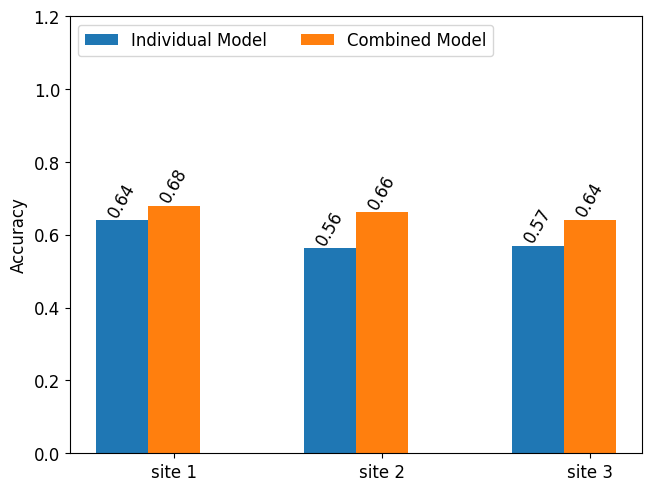

In [80]:
plt.rcParams.update({'font.size': 12})
plot_comparison(0.640, 0.563, 0.570, 0.680, 0.663, 0.642,
                 "Fed_breast_cancer_10_avg.png")

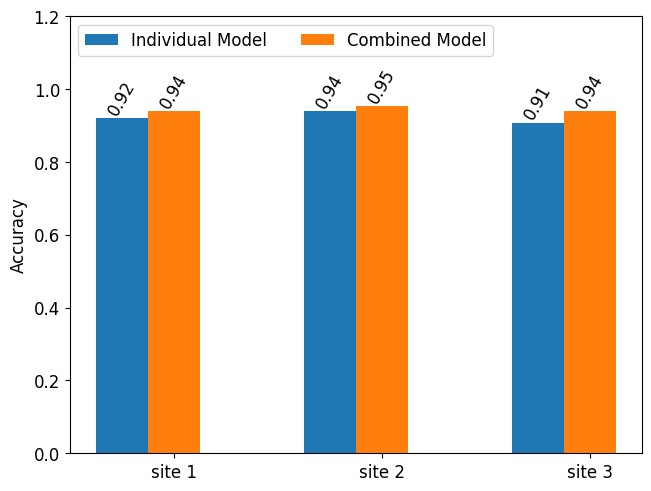

In [81]:
plot_comparison(0.921, 0.939, 0.908, 0.939, 0.953, 0.939,
                 "Fed_breast_cancer_Wisconsin_10_avg.png")

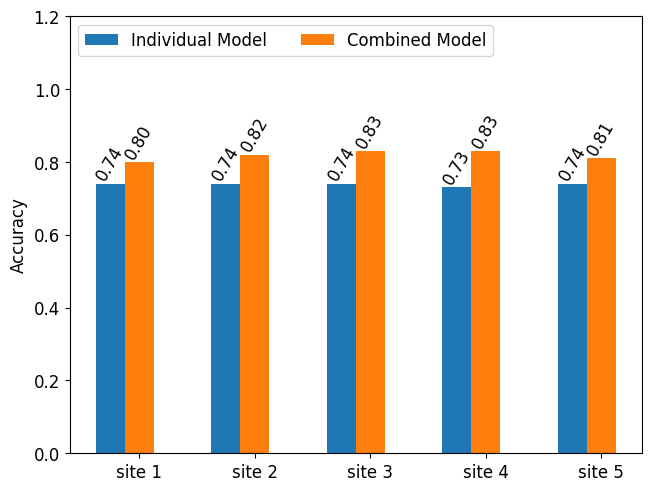

In [86]:
plot_comparison(0.74, 0.74, 0.74, 0.73, 0.74, 
                0.80, 0.82, 0.83, 0.83, 0.81,
                 "Fed_STMFR_10_avg.png")